In [3]:
import pickle
import math
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from structure import read_xyz_traj
from MoREAT.src.representation import generate_representation
from collective_variable import collective_variables
import matplotlib.pyplot as plt

In [4]:

def RMSE(true, pred):
    RMSE_value = 0.0
    N = 0
    #print(true, len(true))
    for i in range(len(true)):
        if(math.isnan(true[i])):
            continue
        if(math.isnan(pred[i])):
            continue
        RMSE_value += (pred[i] - true[i]) ** 2
        N += 1
    RMSE_value = math.sqrt(RMSE_value/N)
    return RMSE_value

In [5]:
"""system_list: The trajectory for training set"""
training_set = read_xyz_traj('Al2F2_CCSDt_energy_MP2_force_training_set.xyz')
CVs_list = [['inverse_r_exp_r', np.array([1, 2]), np.array([3, 4])], ['inverse_r_exp_r', np.array([1, 4]), np.array([2, 3])]]

additional_features = collective_variables(CVs_list=CVs_list)

if type(training_set) != list:
    raise ValueError
if len(training_set) < 1:
    raise Exception('The training set has no system.')
representation_list = generate_representation(training_set).inverse_r_exp_r()
#x_train = np.loadtxt('training_set_representation')
addional_features_list = additional_features.generate_CV_min_list(training_set)
x_train_all = np.hstack((representation_list,addional_features_list))
#x_train = np.where(x_train > 1e+10, 1e+10, x_train)
np.savetxt('training_set_representation_all',x_train_all)

potential_energy_list = np.array([i_system.get_potential_energy() for i_system in training_set])
y_train_all = potential_energy_list
np.savetxt('training_set_label_all',y_train_all)




In [6]:

index_valid = np.random.choice(np.array(range(len(x_train_all))),3000,replace=False)
print("Validation index:", len(index_valid), index_valid)
index_train = np.setdiff1d(range(len(x_train_all)), index_valid)
print("Training index:", len(index_train), index_train)
#index_train = np.array(range(0,len(x_train_all),10))
index_train_selected = index_train[np.array(range(0,len(index_train),10))]
print("Training index used in the training: (", len(index_train_selected), ")", index_train_selected)


x_train = x_train_all[index_train_selected]
np.savetxt('training_set_representation',x_train)

y_train = y_train_all[index_train_selected]
np.savetxt('training_set_label',y_train)


x_valid = x_train_all[index_valid]
y_valid = y_train_all[index_valid]




Validation index: 3000 [19806  1951  7063 ... 19123  9666  1986]
Training index: 19821 [    0     2     3 ... 22818 22819 22820]
Training index used in the training: ( 1983 ) [    0    17    28 ... 22799 22810 22820]


In [7]:


gpr_kernel=kernels.Matern(nu=2.5)*kernels.DotProduct(sigma_0=10)  + kernels.WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-7,1e5))
print("Training set:\n\tShape of feature: "+str(np.shape(x_train))+"\n")
print("\tShape of label: "+str(np.shape(y_train))+"\n")
gpr = GaussianProcessRegressor(kernel=gpr_kernel,normalize_y=True)
gpr.fit(x_train, y_train)
with open('trained_ml_potential_model.pkl','wb') as trained_model_file:
    pickle.dump(gpr, trained_model_file)
print("The trained kernel: "+str(gpr.kernel_)+"\n")
y_train_pred, y_train_pred_std = gpr.predict(x_train, return_std=True)
print("Training RMSE: "+str(RMSE(y_train, y_train_pred)))
print("Average training uncertainty: "+str(np.average(y_train_pred_std)))
print("Median training uncertainty: ", np.median(y_train_pred_std), "\n")


y_valid_pred, y_valid_pred_std = gpr.predict(x_valid, return_std=True)
print("Validation RMSE: "+str(RMSE(y_valid, y_valid_pred)))
print("Average validation uncertainty: "+str(np.average(y_valid_pred_std)))
print("Median validation uncertainty: ", np.median(y_valid_pred_std))



Training set:
	Shape of feature: (1983, 14)

	Shape of label: (1983,)



C:\Users\which\AppData\Roaming\Python\Python38\site-packages\sklearn\gaussian_process\kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


The trained kernel: Matern(length_scale=0.906, nu=2.5) * DotProduct(sigma_0=0.00963) + WhiteKernel(noise_level=1e-07)

Training RMSE: 7.919574520747909e-05
Average training uncertainty: 0.0003374429666730167
Median training uncertainty:  0.0003337903674244061 

Validation RMSE: 0.024486523899699675
Average validation uncertainty: 0.0018238090413906151
Median validation uncertainty:  0.00037186515159203345


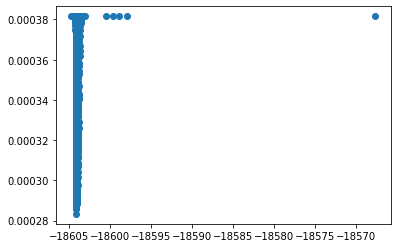

In [8]:
plt.scatter(y_train_pred,y_train_pred_std)

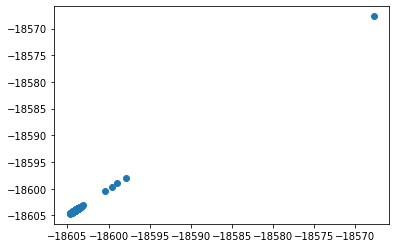

In [9]:
plt.scatter(y_train_pred,y_train)

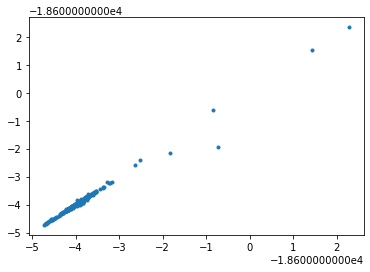

In [10]:
plt.plot(y_valid, y_valid_pred, '.')